# The two-dimensional Ising model

## From a lattice Hamiltonian to a Monte Carlo experiment

This notebook develops an executable model of the ferromagnetic Ising model on a two-dimensional square lattice. The emphasis is on keeping four layers distinct:

1. **Physics:** the state space, Hamiltonian, temperature, and observables.
2. **Mathematics:** the Boltzmann distribution and a Markov transition kernel satisfying detailed balance.
3. **Numerics:** a finite periodic lattice sampled for a finite number of correlated Monte Carlo sweeps.
4. **Implementation:** NumPy arrays, local energy differences, random proposals, and diagnostic plots.

The notebook uses dimensionless units $J=k_{\mathrm{B}}=1$ unless explicitly stated otherwise.

## Learning objectives

After completing the notebook, you should be able to:

- define the configuration space $\Omega=\{-1,+1\}^{L\times L}$;
- implement periodic boundary conditions on a square lattice;
- compute the energy without double-counting nearest-neighbor bonds;
- derive and verify the local energy change $\Delta E$ for one spin flip;
- implement a Metropolis single-spin transition rule;
- distinguish equilibration sweeps, measurement sweeps, and stored samples;
- estimate energy, magnetization, heat capacity, and susceptibility;
- identify the finite-size signature of the critical point;
- explain why Monte Carlo samples are correlated and why critical slowing down matters.

## 1. Model, state space, and boundary conditions

On an $L\times L$ square lattice, each site $(i,j)$ carries a classical spin

$$
s_{ij}\in\{-1,+1\}.
$$

A microstate is the complete spin configuration

$$
\sigma=\{s_{ij}\}\in\Omega,
\qquad
\Omega=\{-1,+1\}^{L\times L},
$$

so the finite system has $|\Omega|=2^{L^2}$ possible states. The Hamiltonian is

$$
H(\sigma)
=
-J\sum_{\langle a,b\rangle}s_a s_b
-h\sum_a s_a,
$$

where $J$ is the nearest-neighbor coupling, $h$ is the external field, and $\langle a,b\rangle$ denotes an unordered nearest-neighbor pair. We take $J>0$, so parallel neighbors lower the energy.

We impose periodic boundary conditions,

$$
s_{i+L,j}=s_{i,j},
\qquad
s_{i,j+L}=s_{i,j},
$$

which make the finite lattice topologically equivalent to a torus. Every site then has coordination number $z=4$. There are $2L^2$ distinct nearest-neighbor bonds, so the fully aligned zero-field state has

$$
E_0=-2JL^2.
$$

The equilibrium probability of a configuration is

$$
\pi(\sigma)=\frac{e^{-\beta H(\sigma)}}{Z},
\qquad
Z=\sum_{\sigma\in\Omega}e^{-\beta H(\sigma)},
\qquad
\beta=\frac{1}{k_{\mathrm{B}}T}.
$$

Directly summing all $2^{L^2}$ configurations becomes impossible very quickly. Monte Carlo sampling replaces exhaustive enumeration with a stochastic trajectory whose long-run distribution is $\pi$.

In [1]:
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
MASTER_SEED = 20260804
rng = np.random.default_rng(MASTER_SEED)

print(f"NumPy version: {np.__version__}")
print(f"Reproducible random seed: {MASTER_SEED}")

NumPy version: 2.5.1
Reproducible random seed: 20260804


## 2. Numerical representation

The physical spin $s_{ij}$ is stored as one entry of an integer array `spins[i, j]`. This array is the numerical representation of $\sigma$; it is not a new physical object.

The energy routine below counts only the bond from each site to its right neighbor and its downward neighbor. Every undirected bond is therefore included exactly once.

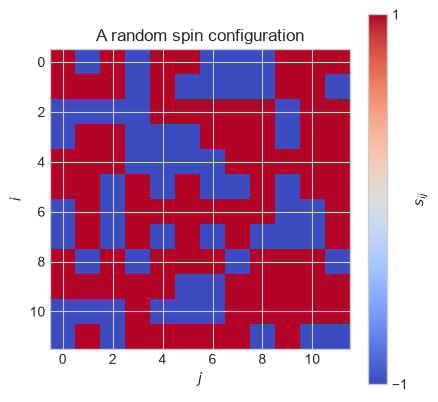

Array shape: (12, 12)
Allowed stored values: [-1  1]
Energy: -16.0
Magnetization: 28


In [2]:
def initialize_lattice(L, state="random", rng=None):
    '''Return an L x L array with entries in {-1, +1}.'''
    if L < 2:
        raise ValueError("L must be at least 2.")
    if rng is None:
        rng = np.random.default_rng()

    if state == "random":
        return rng.choice(np.array([-1, 1], dtype=np.int8), size=(L, L))
    if state == "up":
        return np.ones((L, L), dtype=np.int8)
    if state == "down":
        return -np.ones((L, L), dtype=np.int8)
    raise ValueError("state must be 'random', 'up', or 'down'.")


def total_energy(spins, J=1.0, h=0.0):
    '''Hamiltonian with periodic boundaries; each bond is counted once.'''
    right = np.roll(spins, shift=-1, axis=1)
    down = np.roll(spins, shift=-1, axis=0)
    interaction = -J * np.sum(spins * (right + down))
    field = -h * np.sum(spins)
    return float(interaction + field)


def total_magnetization(spins):
    '''Extensive magnetization M = sum_i s_i.'''
    return int(np.sum(spins))


L_demo = 12
spins_demo = initialize_lattice(L_demo, state="random", rng=rng)

fig, ax = plt.subplots(figsize=(4.5, 4.2))
image = ax.imshow(spins_demo, cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
ax.set(title="A random spin configuration", xlabel="$j$", ylabel="$i$")
plt.colorbar(image, ax=ax, ticks=[-1, 1], label="$s_{ij}$")
plt.tight_layout()
plt.show()

print("Array shape:", spins_demo.shape)
print("Allowed stored values:", np.unique(spins_demo))
print("Energy:", total_energy(spins_demo))
print("Magnetization:", total_magnetization(spins_demo))

## 3. Local spin flips and the energy difference

Suppose the spin at site $(i,j)$ changes from $s_{ij}$ to $-s_{ij}$. Only its four bonds and its field term change. If

$$
S_{ij}^{(\mathrm{nn})}
=s_{i+1,j}+s_{i-1,j}+s_{i,j+1}+s_{i,j-1},
$$

then

$$
\boxed{\Delta E
=2s_{ij}\left(JS_{ij}^{(\mathrm{nn})}+h\right).}
$$

Computing $\Delta E$ locally is $O(1)$, whereas recomputing the full energy after every proposal is $O(L^2)$. This is the central computational reduction in a local-update algorithm.

In [3]:
def delta_energy(spins, i, j, J=1.0, h=0.0):
    '''Energy change produced by flipping spins[i, j].'''
    Lx, Ly = spins.shape
    s = spins[i, j]
    neighbor_sum = (
        spins[(i + 1) % Lx, j]
        + spins[(i - 1) % Lx, j]
        + spins[i, (j + 1) % Ly]
        + spins[i, (j - 1) % Ly]
    )
    return float(2.0 * s * (J * neighbor_sum + h))


def verify_energy_bookkeeping():
    '''Deterministic checks of boundaries, bond counting, and local Delta E.'''
    for L in (4, 7):
        aligned = initialize_lattice(L, state="up", rng=np.random.default_rng(0))
        assert np.isclose(total_energy(aligned), -2.0 * L**2)
        assert total_magnetization(aligned) == L**2
        assert np.isclose(delta_energy(aligned, 0, 0), 8.0)

    test_rng = np.random.default_rng(17)
    spins = initialize_lattice(9, state="random", rng=test_rng)
    for _ in range(50):
        i, j = test_rng.integers(0, 9, size=2)
        before = total_energy(spins, J=1.3, h=0.2)
        predicted = delta_energy(spins, i, j, J=1.3, h=0.2)
        spins[i, j] *= -1
        after = total_energy(spins, J=1.3, h=0.2)
        assert np.isclose(after - before, predicted)

    return "All energy-bookkeeping checks passed."


print(verify_energy_bookkeeping())

All energy-bookkeeping checks passed.


### Checkpoint

Before continuing, explain why flipping one spin in the aligned $h=0$ state gives $\Delta E=8J$. Your explanation should identify both the number of affected bonds and the energy change of each bond.

## 4. The Metropolis transition rule

For a proposed move $\sigma\rightarrow\sigma'$, the Metropolis acceptance probability is

$$
A(\sigma\rightarrow\sigma')
=\min\left(1,e^{-\beta\Delta E}\right),
\qquad
\Delta E=H(\sigma')-H(\sigma).
$$

Thus:

- if $\Delta E\le 0$, accept the move;
- if $\Delta E>0$, accept it with probability $e^{-\Delta E/T}$ in units $k_{\mathrm{B}}=1$.

With symmetric single-spin proposals, this rule satisfies detailed balance,

$$
\pi(\sigma)P(\sigma\rightarrow\sigma')
=
\pi(\sigma')P(\sigma'\rightarrow\sigma).
$$

Together with ergodicity at $T>0$, detailed balance makes the Boltzmann distribution stationary. One **Monte Carlo sweep** consists of $N=L^2$ attempted single-spin updates. A sweep is a unit of algorithmic work, not physical time.

In [4]:
def metropolis_sweep(spins, T, rng, J=1.0, h=0.0):
    '''Attempt N random-site Metropolis updates in place; return acceptance fraction.'''
    if T <= 0:
        raise ValueError("T must be positive for the Metropolis sampler.")

    Lx, Ly = spins.shape
    n_sites = Lx * Ly
    accepted = 0

    for _ in range(n_sites):
        i = rng.integers(0, Lx)
        j = rng.integers(0, Ly)
        dE = delta_energy(spins, i, j, J=J, h=h)

        if dE <= 0.0 or rng.random() < np.exp(-dE / T):
            spins[i, j] *= -1
            accepted += 1

    return accepted / n_sites


@dataclass
class IsingTimeSeries:
    temperature: float
    energies: np.ndarray
    magnetizations: np.ndarray
    acceptance_fraction: float


def run_chain(
    L,
    T,
    n_equilibration=400,
    n_measurement=1000,
    sample_every=5,
    J=1.0,
    h=0.0,
    initial=None,
    rng=None,
):
    '''Equilibrate, sample a Metropolis chain, and return its final state and time series.'''
    if rng is None:
        rng = np.random.default_rng()
    if sample_every < 1:
        raise ValueError("sample_every must be at least 1.")

    spins = (
        initialize_lattice(L, state="random", rng=rng)
        if initial is None
        else np.array(initial, dtype=np.int8, copy=True)
    )
    if spins.shape != (L, L):
        raise ValueError("initial must have shape (L, L).")

    for _ in range(n_equilibration):
        metropolis_sweep(spins, T, rng, J=J, h=h)

    energies = []
    magnetizations = []
    acceptance = []

    for sweep in range(n_measurement):
        acceptance.append(metropolis_sweep(spins, T, rng, J=J, h=h))
        if sweep % sample_every == 0:
            energies.append(total_energy(spins, J=J, h=h))
            magnetizations.append(total_magnetization(spins))

    series = IsingTimeSeries(
        temperature=float(T),
        energies=np.asarray(energies, dtype=float),
        magnetizations=np.asarray(magnetizations, dtype=float),
        acceptance_fraction=float(np.mean(acceptance)),
    )
    return spins, series

## 5. Ordered, critical, and disordered regimes

For the infinite square-lattice Ising model at $h=0$, the exact critical temperature is

$$
\boxed{
\frac{k_{\mathrm{B}}T_c}{J}
=\frac{2}{\ln(1+\sqrt{2})}
\approx 2.269185.
}
$$

The finite lattice has no true nonanalytic phase transition. Instead, it exhibits rounded, size-dependent signatures near $T_c$.

The next experiment starts each temperature from the same random configuration, equilibrates it, and then stores one measurement every five sweeps. Compare the configurations and magnetization traces at low, near-critical, and high temperature.

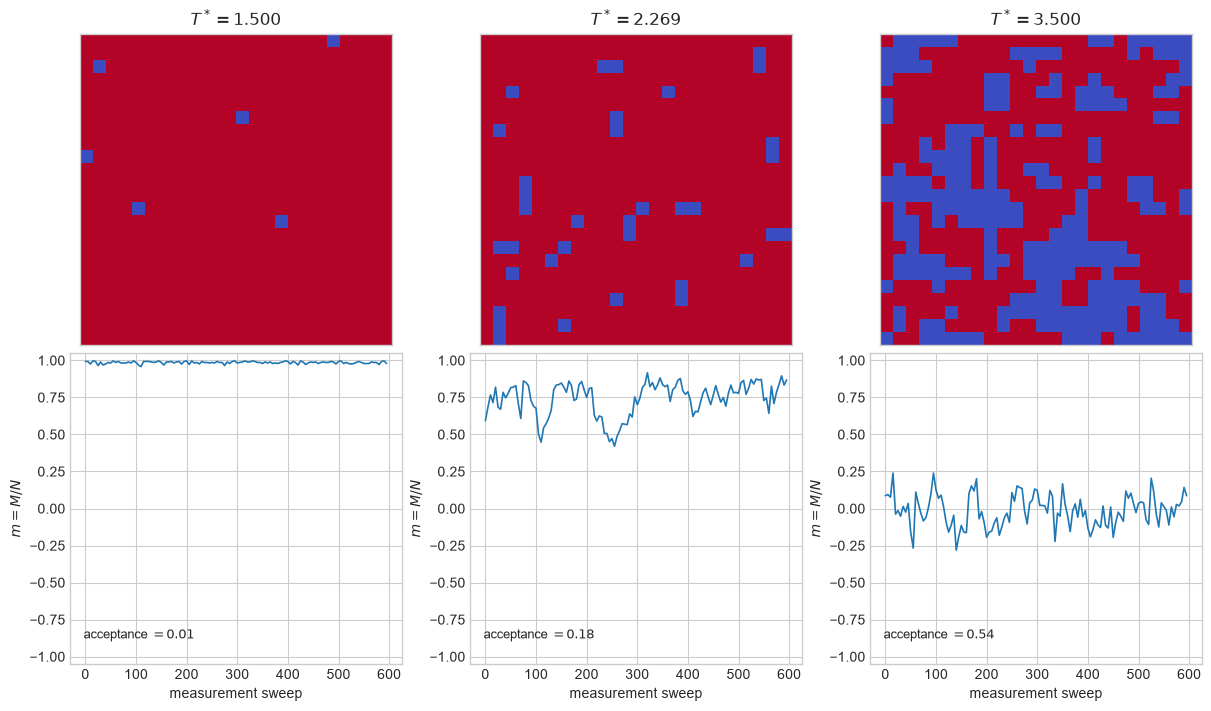

In [5]:
TC_EXACT = 2.0 / np.log(1.0 + np.sqrt(2.0))
temperatures_demo = [1.5, TC_EXACT, 3.5]
L_snapshot = 24
base_state = initialize_lattice(L_snapshot, state="random", rng=np.random.default_rng(91))

snapshot_states = []
snapshot_series = []

for index, T in enumerate(temperatures_demo):
    local_rng = np.random.default_rng(MASTER_SEED + 100 + index)
    final_state, series = run_chain(
        L=L_snapshot,
        T=T,
        n_equilibration=350,
        n_measurement=600,
        sample_every=5,
        initial=base_state,
        rng=local_rng,
    )
    snapshot_states.append(final_state)
    snapshot_series.append(series)

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

for column, (T, state, series) in enumerate(
    zip(temperatures_demo, snapshot_states, snapshot_series)
):
    axes[0, column].imshow(
        state, cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest"
    )
    axes[0, column].set_title(rf"$T^*={T:.3f}$")
    axes[0, column].set_xticks([])
    axes[0, column].set_yticks([])

    m = series.magnetizations / L_snapshot**2
    axes[1, column].plot(np.arange(len(m)) * 5, m, lw=1.2)
    axes[1, column].set(xlabel="measurement sweep", ylabel="$m=M/N$", ylim=(-1.05, 1.05))
    axes[1, column].text(
        0.04,
        0.08,
        rf"acceptance $={series.acceptance_fraction:.2f}$",
        transform=axes[1, column].transAxes,
        fontsize=9,
    )

plt.show()

### Interpret the experiment

1. Why is the acceptance fraction smaller at low temperature?
2. Why do large same-spin domains form near $T_c$?
3. Why does a local-update algorithm decorrelate slowly near $T_c$?
4. Does the plotted sweep number represent laboratory time? Explain.

The slow evolution of large domains near $T_c$ is **critical slowing down**. It increases autocorrelation times and makes naive uncertainty estimates too small.

## 6. Thermodynamic observables from fluctuations

For $N=L^2$ sites, define energy per spin and magnetization per spin by

$$
e=\frac{\langle E\rangle}{N},
\qquad
m=\frac{\langle M\rangle}{N}.
$$

At zero field, spin-inversion symmetry gives $\langle M\rangle=0$ for an exactly sampled finite system. A finite local-update run below $T_c$ may remain trapped in one magnetized sector. We therefore plot $\langle|M|\rangle/N$ as a finite-size order parameter.

The heat capacity per spin follows from energy fluctuations,

$$
c_V
=\frac{\langle E^2\rangle-\langle E\rangle^2}{NT^2},
$$

and we use the symmetry-aware finite-run susceptibility estimator

$$
\chi_{|M|}
=\frac{\langle M^2\rangle-\langle|M|\rangle^2}{NT}.
$$

The standard zero-field susceptibility instead contains $\langle M\rangle^2$. The two estimators answer slightly different finite-size sampling questions and become especially sensitive to phase switching near the transition.

Because successive samples are correlated, the code estimates standard errors with a delete-one-block jackknife over contiguous blocks rather than treating every stored state as independent.

In [6]:
def observable_estimates(series, n_sites, block_size=10):
    '''Return full-sample estimates and delete-one-block jackknife errors.'''
    E = np.asarray(series.energies, dtype=float)
    M = np.asarray(series.magnetizations, dtype=float)
    n_blocks = len(E) // block_size
    if n_blocks < 2:
        raise ValueError("Need at least two complete blocks.")

    E = E[: n_blocks * block_size]
    M = M[: n_blocks * block_size]
    T = series.temperature

    def statistics(energy, magnetization):
        return np.array(
            [
                np.mean(energy) / n_sites,
                np.mean(np.abs(magnetization)) / n_sites,
                (np.mean(energy**2) - np.mean(energy) ** 2) / (n_sites * T**2),
                (np.mean(magnetization**2) - np.mean(np.abs(magnetization)) ** 2)
                / (n_sites * T),
            ]
        )

    full = statistics(E, M)
    leave_one_block_out = []
    for block in range(n_blocks):
        keep = np.ones(len(E), dtype=bool)
        start = block * block_size
        keep[start : start + block_size] = False
        leave_one_block_out.append(statistics(E[keep], M[keep]))

    leave_one_block_out = np.asarray(leave_one_block_out)
    leave_mean = np.mean(leave_one_block_out, axis=0)
    standard_error = np.sqrt(
        (n_blocks - 1) / n_blocks
        * np.sum((leave_one_block_out - leave_mean) ** 2, axis=0)
    )

    names = ("energy", "abs_magnetization", "heat_capacity", "susceptibility_abs")
    return {
        name: {"mean": float(mean), "se": float(se)}
        for name, mean, se in zip(names, full, standard_error)
    }


def scan_temperatures(
    L,
    temperatures,
    n_equilibration=200,
    n_measurement=500,
    sample_every=5,
    block_size=10,
    seed=1234,
):
    '''Warm-start an increasing-temperature scan and return observable arrays.'''
    scan_rng = np.random.default_rng(seed)
    spins = initialize_lattice(L, state="up", rng=scan_rng)
    rows = []

    for T in temperatures:
        spins, series = run_chain(
            L=L,
            T=float(T),
            n_equilibration=n_equilibration,
            n_measurement=n_measurement,
            sample_every=sample_every,
            initial=spins,
            rng=scan_rng,
        )
        estimates = observable_estimates(series, L**2, block_size=block_size)
        rows.append(
            {
                "T": float(T),
                "acceptance": series.acceptance_fraction,
                **{
                    f"{name}_{part}": value[part]
                    for name, value in estimates.items()
                    for part in ("mean", "se")
                },
            }
        )

    return rows

## 7. Temperature scan

This scan is intentionally moderate so the notebook remains usable in class. It is a numerical experiment, not a high-precision determination of critical exponents. Increase the lattice size and the run lengths only after checking equilibration and autocorrelation.

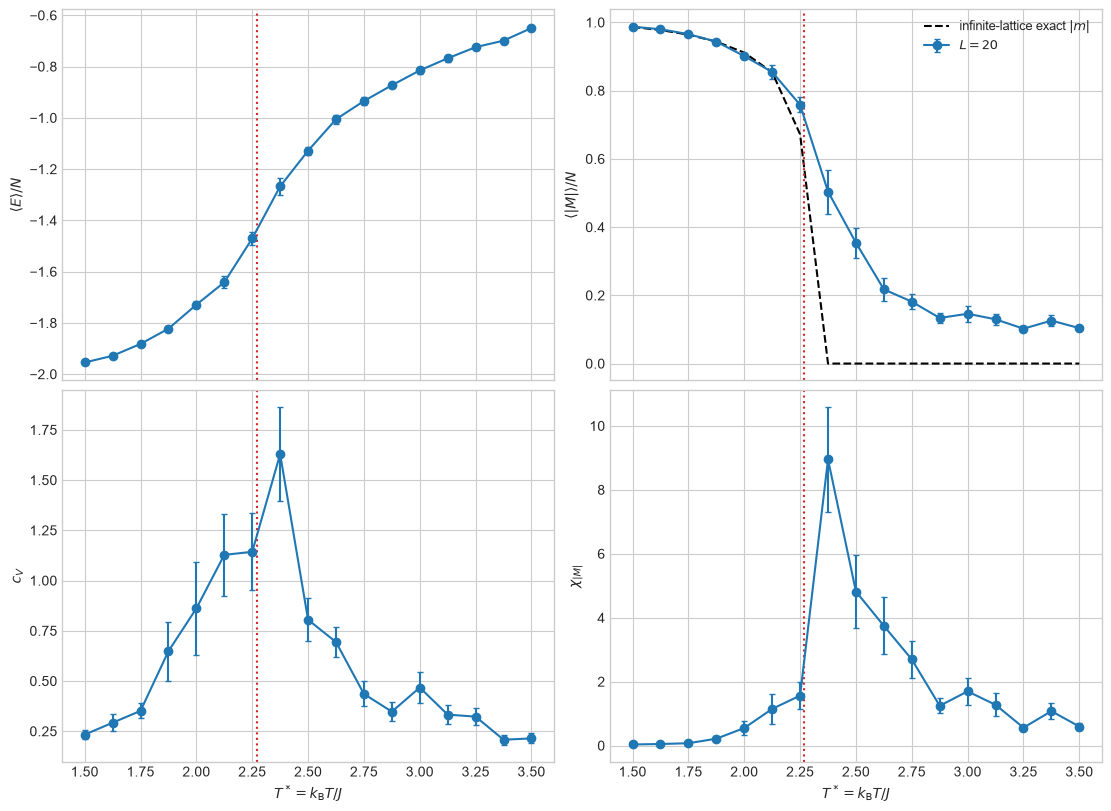

Exact infinite-lattice critical temperature: 2.269185
Largest sampled heat-capacity value occurs at T* = 2.375
Largest sampled susceptibility value occurs at T* = 2.375
These peak locations are grid-dependent, noisy finite-size pseudocritical estimates.


In [7]:
L_scan = 20
temperatures = np.linspace(1.5, 3.5, 17)

scan = scan_temperatures(
    L=L_scan,
    temperatures=temperatures,
    n_equilibration=200,
    n_measurement=500,
    sample_every=5,
    block_size=10,
    seed=MASTER_SEED + 500,
)


def column(rows, name):
    return np.array([row[name] for row in rows], dtype=float)


T_values = column(scan, "T")
e_values = column(scan, "energy_mean")
e_errors = column(scan, "energy_se")
m_values = column(scan, "abs_magnetization_mean")
m_errors = column(scan, "abs_magnetization_se")
cv_values = column(scan, "heat_capacity_mean")
cv_errors = column(scan, "heat_capacity_se")
chi_values = column(scan, "susceptibility_abs_mean")
chi_errors = column(scan, "susceptibility_abs_se")

exact_m = np.zeros_like(T_values)
ordered = T_values < TC_EXACT
exact_m[ordered] = (
    1.0 - np.sinh(2.0 / T_values[ordered]) ** (-4)
) ** (1.0 / 8.0)

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, constrained_layout=True)

axes[0, 0].errorbar(T_values, e_values, yerr=e_errors, marker="o", capsize=2)
axes[0, 0].set_ylabel(r"$\langle E\rangle/N$")

axes[0, 1].errorbar(T_values, m_values, yerr=m_errors, marker="o", capsize=2, label=rf"$L={L_scan}$")
axes[0, 1].plot(T_values, exact_m, "k--", label="infinite-lattice exact $|m|$")
axes[0, 1].set_ylabel(r"$\langle |M|\rangle/N$")
axes[0, 1].legend(fontsize=9)

axes[1, 0].errorbar(T_values, cv_values, yerr=cv_errors, marker="o", capsize=2)
axes[1, 0].set(xlabel=r"$T^*=k_{\mathrm{B}}T/J$", ylabel=r"$c_V$")

axes[1, 1].errorbar(T_values, chi_values, yerr=chi_errors, marker="o", capsize=2)
axes[1, 1].set(xlabel=r"$T^*=k_{\mathrm{B}}T/J$", ylabel=r"$\chi_{|M|}$")

for ax in axes.flat:
    ax.axvline(TC_EXACT, color="tab:red", ls=":", lw=1.5)

plt.show()

cv_peak_T = T_values[np.argmax(cv_values)]
chi_peak_T = T_values[np.argmax(chi_values)]
print(f"Exact infinite-lattice critical temperature: {TC_EXACT:.6f}")
print(f"Largest sampled heat-capacity value occurs at T* = {cv_peak_T:.3f}")
print(f"Largest sampled susceptibility value occurs at T* = {chi_peak_T:.3f}")
print("These peak locations are grid-dependent, noisy finite-size pseudocritical estimates.")

### What the plots do—and do not—show

- The rapid loss of $\langle|M|\rangle/N$ marks the order-disorder crossover of the finite lattice.
- Peaks in $c_V$ and $\chi_{|M|}$ are finite-size precursors of singular thermodynamic-limit behavior.
- The measured peak temperature need not equal the exact $T_c$: it depends on $L$, temperature resolution, equilibration, run length, and estimator choice.
- Error bars from blocking address part of the sampling uncertainty. They do not remove finite-size bias, initialization bias, or discretization in the temperature grid.

The exact spontaneous magnetization plotted above is

$$
m_{\infty}(T)
=
\begin{cases}
\left[1-\sinh^{-4}(2J/k_{\mathrm{B}}T)\right]^{1/8}, & T<T_c,\
0, & T\ge T_c.
\end{cases}
$$

Agreement should improve away from $T_c$ as $L$ and the number of effectively independent samples increase.

## 8. Autocorrelation diagnostic

For a stationary scalar series $x_t$, define the normalized autocorrelation at lag $\ell$ by

$$
\rho(\ell)
=
\frac{\langle (x_t-\bar{x})(x_{t+\ell}-\bar{x})\rangle}
{\langle (x_t-\bar{x})^2\rangle}.
$$

Slow decay means that stored samples carry less independent information than their count suggests. The following simple estimator is suitable for qualitative diagnosis; production work should use longer runs and a robust integrated-autocorrelation analysis.

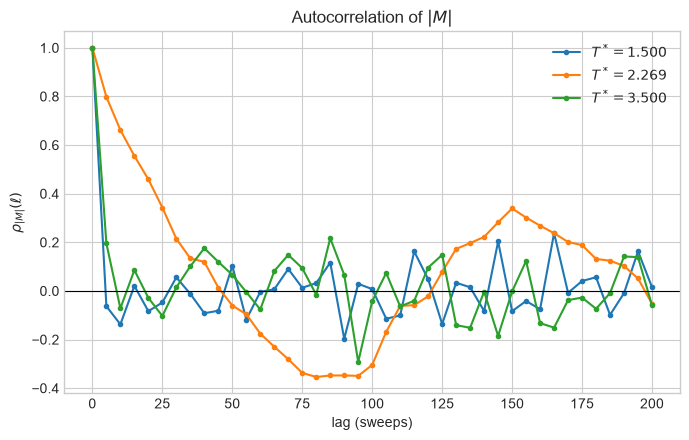

In [8]:
def normalized_autocorrelation(values, max_lag=50):
    x = np.asarray(values, dtype=float)
    x = x - np.mean(x)
    variance = np.dot(x, x) / len(x)
    if variance == 0:
        return np.ones(max_lag + 1)
    max_lag = min(max_lag, len(x) - 1)
    return np.array(
        [np.dot(x[:-lag], x[lag:]) / ((len(x) - lag) * variance) if lag else 1.0
         for lag in range(max_lag + 1)]
    )


fig, ax = plt.subplots(figsize=(7, 4.5))
for T, series in zip(temperatures_demo, snapshot_series):
    rho = normalized_autocorrelation(np.abs(series.magnetizations), max_lag=40)
    lags_in_sweeps = np.arange(len(rho)) * 5
    ax.plot(lags_in_sweeps, rho, marker="o", ms=3, label=rf"$T^*={T:.3f}$")

ax.axhline(0, color="black", lw=0.8)
ax.set(xlabel="lag (sweeps)", ylabel=r"$\rho_{|M|}(\ell)$", title="Autocorrelation of $|M|$")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Optional finite-size experiment

Set `RUN_FINITE_SIZE_SCALING = True` to compare several lattice sizes near $T_c$. This extension is off by default because a convincing finite-size study requires substantially longer chains than the introductory scan.

For a systematic analysis, add the Binder cumulant

$$
U_4
=1-\frac{\langle M^4\rangle}{3\langle M^2\rangle^2}.
$$

Curves of $U_4(T,L)$ for different $L$ approximately cross near $T_c$ and avoid relying only on a noisy peak location.

In [9]:
RUN_FINITE_SIZE_SCALING = False

if RUN_FINITE_SIZE_SCALING:
    sizes = (12, 20, 32)
    finite_T = np.linspace(2.0, 2.55, 12)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

    for index, L in enumerate(sizes):
        rows = scan_temperatures(
            L=L,
            temperatures=finite_T,
            n_equilibration=350,
            n_measurement=800,
            sample_every=5,
            block_size=10,
            seed=MASTER_SEED + 1000 + index,
        )
        axes[0].plot(column(rows, "T"), column(rows, "heat_capacity_mean"), "o-", label=rf"$L={L}$")
        axes[1].plot(column(rows, "T"), column(rows, "susceptibility_abs_mean"), "o-", label=rf"$L={L}$")

    for ax, ylabel in zip(axes, (r"$c_V$", r"$\chi_{|M|}$")):
        ax.axvline(TC_EXACT, color="tab:red", ls=":")
        ax.set(xlabel=r"$T^*$", ylabel=ylabel)
        ax.legend()
    plt.show()
else:
    print("Finite-size extension skipped. Set RUN_FINITE_SIZE_SCALING = True to run it.")

Finite-size extension skipped. Set RUN_FINITE_SIZE_SCALING = True to run it.


## 10. Exercises

### Exercise 1 — Boundary conditions and bond counting

Replace periodic boundaries with open boundaries. Show analytically and numerically that the aligned ground-state energy becomes

$$
E_0^{\mathrm{open}}=-2JL(L-1).
$$

Identify the corner, edge, and interior coordination numbers.

### Exercise 2 — Detailed balance

For symmetric single-spin proposals, derive

$$
\frac{A(\sigma\rightarrow\sigma')}{A(\sigma'\rightarrow\sigma)}
=e^{-\beta\Delta E}
$$

for both signs of $\Delta E$. Explain why detailed balance is sufficient but not necessary for stationarity.

### Exercise 3 — External field

Run temperature scans at $h/J=0.05$, $0.10$, and $0.20$. Determine how a nonzero field changes $\langle M\rangle$, the susceptibility peak, and the distinction between the two magnetized sectors.

### Exercise 4 — Antiferromagnetic coupling

Set $J<0$. Replace the ordinary magnetization with the staggered order parameter

$$
m_s=\frac{1}{N}\sum_{i,j}(-1)^{i+j}s_{ij}.
$$

Verify that the low-temperature state has $|m_s|\approx 1$ on an even periodic lattice. Explain the frustration introduced by an odd $L$ with periodic boundaries.

### Exercise 5 — Finite-size scaling

Run several $L$ values with longer chains. Estimate the pseudocritical temperature from the heat-capacity peak, susceptibility peak, and Binder-cumulant crossings. Report how the results change with temperature-grid spacing.

### Exercise 6 — Critical slowing down

Measure the autocorrelation of $|M|$ for several $L$ values near $T_c$. Compare the single-spin Metropolis method with a Wolff cluster update. State explicitly whether either Monte Carlo trajectory represents real spin dynamics.

### Suggested submission

Submit a short computational report containing:

- the model, units, lattice size, and boundary conditions;
- the update rule and equilibration/sampling protocol;
- at least one deterministic implementation check;
- plots with labeled axes and uncertainty estimates;
- a discussion separating finite-size effects, sampling error, and physical interpretation;
- the random seed and all code needed to reproduce the figures.

## Summary

The two-dimensional Ising model turns a compact Hamiltonian into a complete computational experiment:

$$
\text{state space}
\rightarrow
\text{energy function}
\rightarrow
\text{Markov transition rule}
\rightarrow
\text{sampled observables}.
$$

The local formula for $\Delta E$ makes each attempted update inexpensive. The Metropolis rule samples the Boltzmann distribution under the stated assumptions, but the resulting data remain finite, correlated, and algorithm-dependent. A physically meaningful conclusion therefore requires more than a working loop: it requires validation of the Hamiltonian implementation, equilibration checks, uncertainty analysis, and explicit treatment of finite-size effects.

## References

1. L. Onsager, “Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition,” *Physical Review* **65**, 117–149 (1944).
2. N. Metropolis, A. W. Rosenbluth, M. N. Rosenbluth, A. H. Teller, and E. Teller, “Equation of State Calculations by Fast Computing Machines,” *Journal of Chemical Physics* **21**, 1087–1092 (1953).
3. M. E. J. Newman and G. T. Barkema, *Monte Carlo Methods in Statistical Physics*, Oxford University Press (1999).
4. D. P. Landau and K. Binder, *A Guide to Monte Carlo Simulations in Statistical Physics*, Cambridge University Press.